<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Detecci%C3%B3n_de_Neumonia_con_CNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utsavk02/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 1.14G/1.14G [00:11<00:00, 108MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/utsavk02/chest-xray-pneumonia/versions/1


In [3]:
import os
os.listdir(path)

['test', 'val', 'train']

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import itertools, random

In [4]:
BASE_DIR = path
TRAIN_DIR = BASE_DIR + "/train"
VAL_DIR = BASE_DIR + "/val"
TEST_DIR = BASE_DIR + "/test"

In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation ---
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [12]:
train_flow = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
val_flow = val_gen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
test_flow = test_gen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary",
    shuffle=False
)

print("Clases:", train_flow.class_indices)

Found 4693 images belonging to 2 classes.
Found 539 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Clases: {'NORMAL': 0, 'PNEUMONIA': 1}


In [13]:
# Modelo base MobileNetV2 ---
base_model = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=IMG_SIZE+(3,))
base_model.trainable = False  # Congelado al inicio

# Modelo completo ---
inputs = keras.Input(shape=IMG_SIZE+(3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu",
                 kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.Adam(1e-4),
              loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc")])

model.summary()

# Callbacks ---
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, verbose=1),
    ModelCheckpoint("/content/best_model_mobilenetv2.h5",
                    monitor="val_auc", mode="max",
                    save_best_only=True, verbose=1)
]

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# --- Paso 6: Cálculo de pesos de clase (para balancear) ---
classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_flow.classes
)
class_weights = dict(zip(classes, class_weights))
print("Pesos de clase:", class_weights)


Pesos de clase: {np.int64(0): np.float64(1.9456882255389718), np.int64(1): np.float64(0.6729280183538858)}


In [16]:
# Entrenamiento inicial (solo capas superiores) ---
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

# Fine-tuning (descongelar últimas capas del modelo base) ---
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc")])

fine_history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6991 - auc: 0.7413 - loss: 0.6209
Epoch 1: val_auc improved from None to 0.96495, saving model to /content/best_model_mobilenetv2.h5



Epoch 1: finished saving model to /content/best_model_mobilenetv2.h5
147/147 ━━━━━━━━━━━━━━━━━━━━ 379s 3s/step - accuracy: 0.7959 - auc: 0.8743 - loss: 0.4668 - val_accuracy: 0.8683 - val_auc: 0.9649 - val_loss: 0.2968 - learning_rate: 1.0000e-04
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8945 - auc: 0.9562 - loss: 0.2895
Epoch 2: val_auc improved from 0.96495 to 0.97569, saving model to /content/best_model_mobilenetv2.h5



Epoch 2: finished saving model to /content/best_model_mobilenetv2.h5
147/147 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9018 - auc: 0.9637 - loss: 0.2675 - val_accuracy: 0.8942 - val_auc: 0.9757 - val_loss: 0.2458 - learning_rate: 1.0000e-04
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9142 - auc: 0.9678 - loss: 0.2513
Epoch 3: val_auc did not improve from 0.97569
147/147 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9209 - auc: 0.9739 - loss: 0.2279 - val_accuracy: 0.8776 - val_auc: 0.9754 - val_loss: 0.2907 - learning_rate: 1.0000e-04
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9126 - auc: 0.9757 - loss: 0.2157
Epoch 4: val_auc improved from 0.97569 to 0.97952, saving model to /content/best_model_mobilenetv2.h5



Epoch 4: finished saving model to /content/best_model_mobilenetv2.h5
147/147 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9201 - auc: 0.9767 - loss: 0.2130 - val_accuracy: 0.8868 - val_auc: 0.9795 - val_loss: 0.2704 - learning_rate: 1.0000e-04
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9302 - auc: 0.9815 - loss: 0.1921
Epoch 5: val_auc improved from 0.97952 to 0.98248, saving model to /content/best_model_mobilenetv2.h5



Epoch 5: finished saving model to /content/best_model_mobilenetv2.h5
147/147 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9256 - auc: 0.9802 - loss: 0.1974 - val_accuracy: 0.9091 - val_auc: 0.9825 - val_loss: 0.2098 - learning_rate: 1.0000e-04
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9343 - auc: 0.9820 - loss: 0.1906
Epoch 6: val_auc improved from 0.98248 to 0.98261, saving model to /content/best_model_mobilenetv2.h5



Epoch 6: finished saving model to /content/best_model_mobilenetv2.h5
147/147 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9346 - auc: 0.9832 - loss: 0.1836 - val_accuracy: 0.8961 - val_auc: 0.9826 - val_loss: 0.2520 - learning_rate: 1.0000e-04
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9295 - auc: 0.9838 - loss: 0.1842
Epoch 7: val_auc improved from 0.98261 to 0.98274, saving model to /content/best_model_mobilenetv2.h5



Epoch 7: finished saving model to /content/best_model_mobilenetv2.h5
147/147 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.9333 - auc: 0.9844 - loss: 0.1789 - val_accuracy: 0.8924 - val_auc: 0.9827 - val_loss: 0.2782 - learning_rate: 1.0000e-04
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9362 - auc: 0.9849 - loss: 0.1728
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 8: val_auc improved from 0.98274 to 0.98465, saving model to /content/best_model_mobilenetv2.h5



Epoch 8: finished saving model to /content/best_model_mobilenetv2.h5
147/147 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.9320 - auc: 0.9831 - loss: 0.1822 - val_accuracy: 0.9091 - val_auc: 0.9847 - val_loss: 0.2186 - learning_rate: 1.0000e-04
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9460 - auc: 0.9894 - loss: 0.1543
Epoch 9: val_auc did not improve from 0.98465
147/147 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.9437 - auc: 0.9876 - loss: 0.1594 - val_accuracy: 0.9091 - val_auc: 0.9843 - val_loss: 0.2284 - learning_rate: 5.0000e-05
Epoch 10/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9412 - auc: 0.9877 - loss: 0.1576
Epoch 10: val_auc did not improve from 0.98465
147/147 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.9367 - auc: 0.9868 - loss: 0.1640 - val_accuracy: 0.9109 - val_auc: 0.9844 - val_loss: 0.2167 - learning_rate: 5.0000e-05
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 1/10
147/147 ━

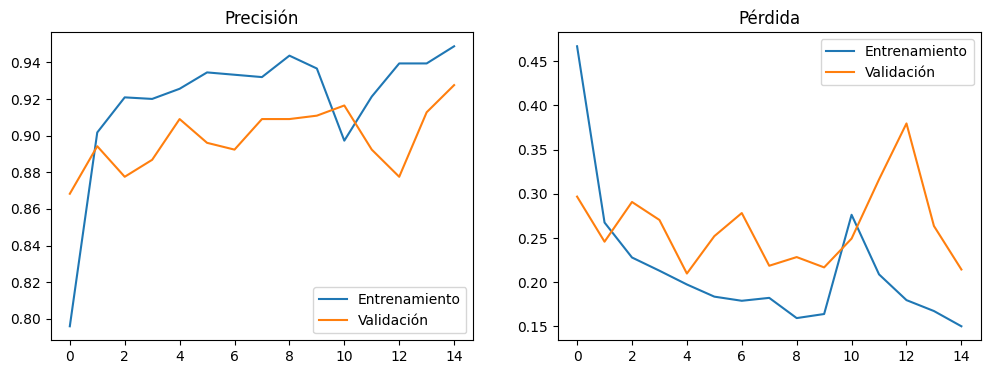

In [17]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"] + fine_history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"] + fine_history.history["val_accuracy"], label="Validación")
plt.legend(); plt.title("Precisión")

plt.subplot(1,2,2)
plt.plot(history.history["loss"] + fine_history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"] + fine_history.history["val_loss"], label="Validación")
plt.legend(); plt.title("Pérdida")
plt.show()

In [18]:
best_model = keras.models.load_model("/content/best_model_mobilenetv2.h5")
test_probs = best_model.predict(test_flow)
test_preds = (test_probs > 0.5).astype(int).ravel()
y_true = test_flow.classes

print(classification_report(y_true, test_preds, target_names=["NORMAL", "PNEUMONIA"]))
print("AUC:", roc_auc_score(y_true, test_probs))

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step
              precision    recall  f1-score   support

      NORMAL       0.91      0.81      0.86       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624

AUC: 0.9678281832127986


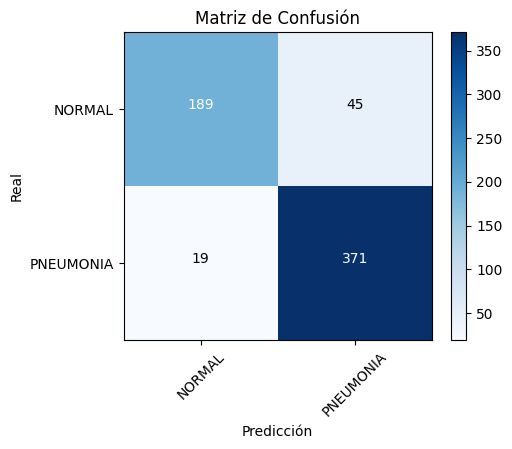

In [19]:
cm = confusion_matrix(y_true, test_preds)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de Confusión")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["NORMAL","PNEUMONIA"], rotation=45)
plt.yticks(tick_marks, ["NORMAL","PNEUMONIA"])
thresh = cm.max()/2
for i, j in itertools.product(range(2), range(2)):
    plt.text(j, i, cm[i,j], ha="center",
             color="white" if cm[i,j] > thresh else "black")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Total de errores: 64 de 624 imágenes


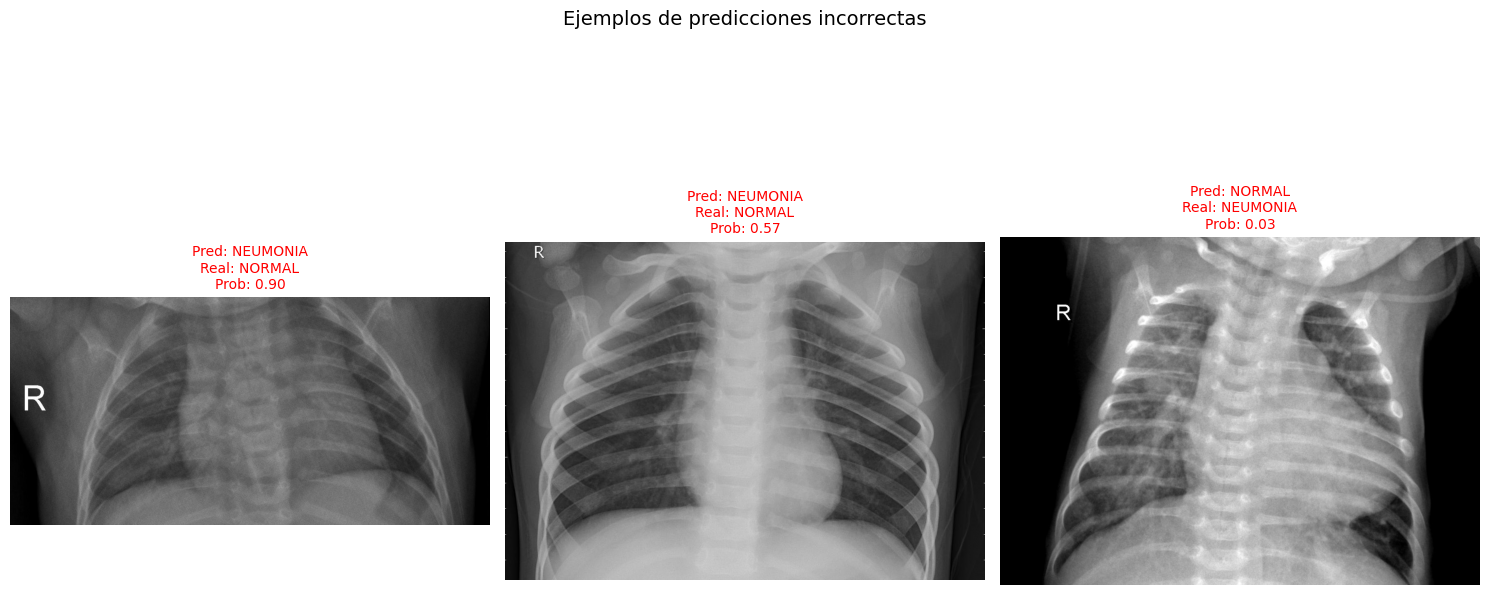

In [20]:
import matplotlib.pyplot as plt
import random
import numpy as np

# --- Predicciones ya calculadas ---
# (Si no tienes las variables cargadas, vuelve a ejecutar el bloque de evaluación)
# test_probs, test_preds, y_true, test_flow

# --- Identificar casos erróneos ---
misclassified = np.where(test_preds != y_true)[0]
print(f"Total de errores: {len(misclassified)} de {len(y_true)} imágenes")

# --- Mostrar ejemplos aleatorios ---
num_examples = min(3, len(misclassified))
samples = random.sample(list(misclassified), num_examples)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(samples, 1):
    img_path = test_flow.filepaths[idx]
    true_label = "NEUMONIA" if y_true[idx] == 1 else "NORMAL"
    pred_label = "NEUMONIA" if test_preds[idx] == 1 else "NORMAL"
    prob = test_probs[idx][0]

    img = plt.imread(img_path)
    plt.subplot(1, num_examples, i)
    plt.imshow(img, cmap="gray")
    plt.title(f"Pred: {pred_label}\nReal: {true_label}\nProb: {prob:.2f}",
              color=("red" if pred_label != true_label else "green"), fontsize=10)
    plt.axis("off")

plt.suptitle("Ejemplos de predicciones incorrectas", fontsize=14)
plt.tight_layout()
plt.show()

Total de aciertos: 560 de 624 imágenes


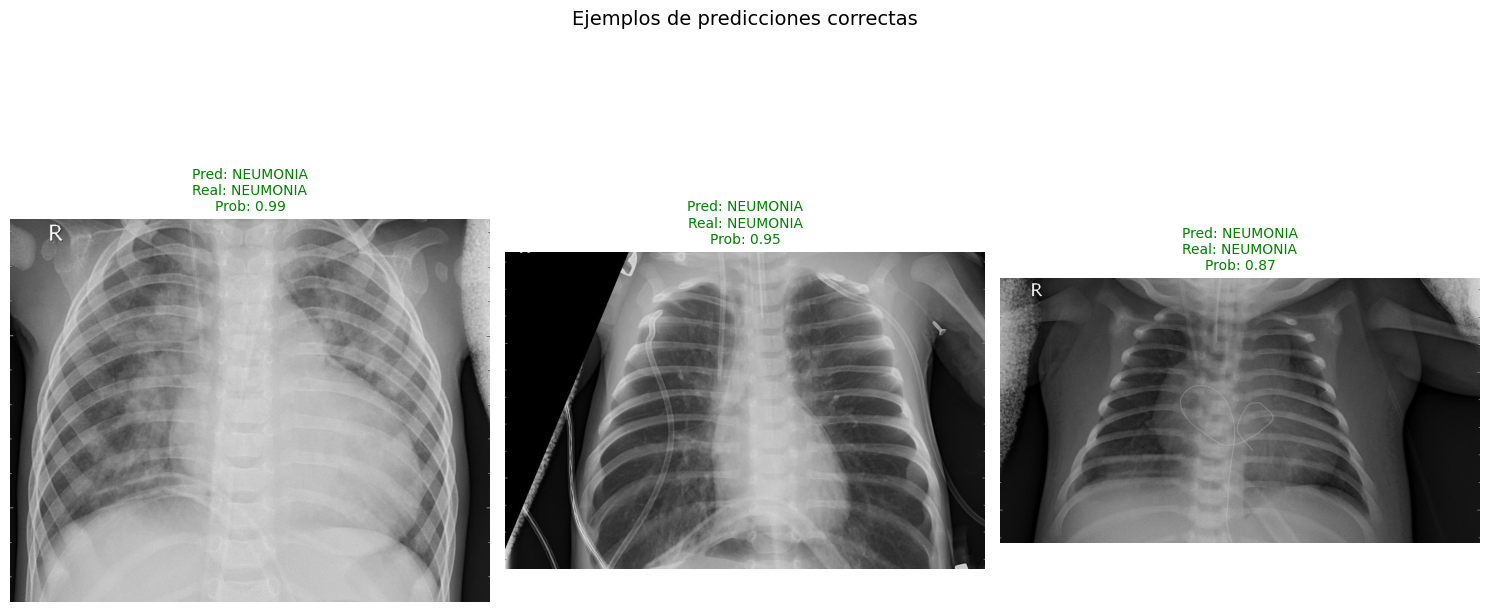

In [21]:
# --- Identificar casos correctos ---
correct = np.where(test_preds == y_true)[0]
print(f"Total de aciertos: {len(correct)} de {len(y_true)} imágenes")

# --- Mostrar ejemplos aleatorios ---
num_examples = min(3, len(correct))
samples = random.sample(list(correct), num_examples)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(samples, 1):
    img_path = test_flow.filepaths[idx]
    true_label = "NEUMONIA" if y_true[idx] == 1 else "NORMAL"
    pred_label = "NEUMONIA" if test_preds[idx] == 1 else "NORMAL"
    prob = test_probs[idx][0]

    img = plt.imread(img_path)
    plt.subplot(1, num_examples, i)
    plt.imshow(img, cmap="gray")
    plt.title(f"Pred: {pred_label}\nReal: {true_label}\nProb: {prob:.2f}",
              color="green", fontsize=10)
    plt.axis("off")

plt.suptitle("Ejemplos de predicciones correctas", fontsize=14)
plt.tight_layout()
plt.show()


✅ Aciertos NORMAL: 189
✅ Aciertos NEUMONIA: 371


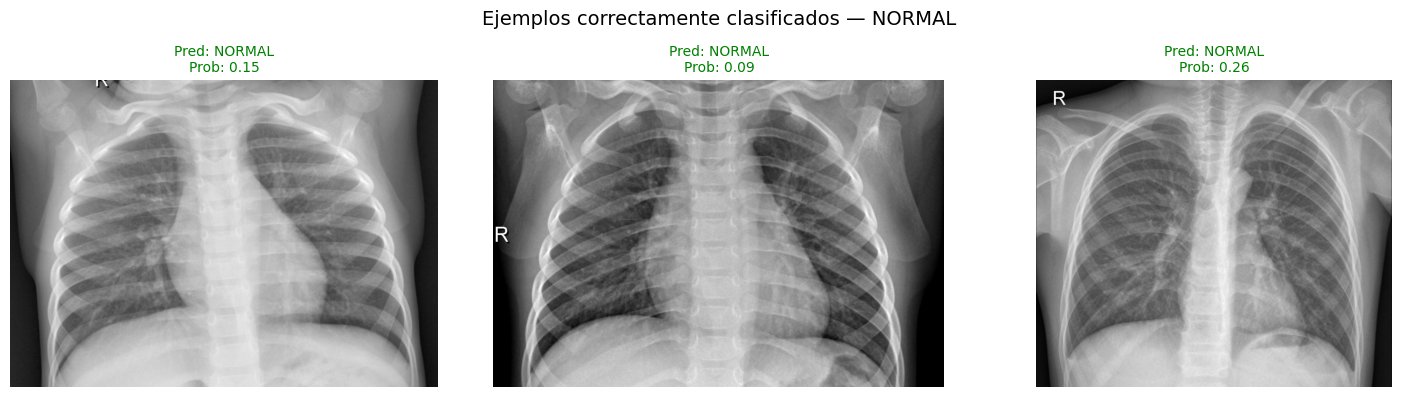

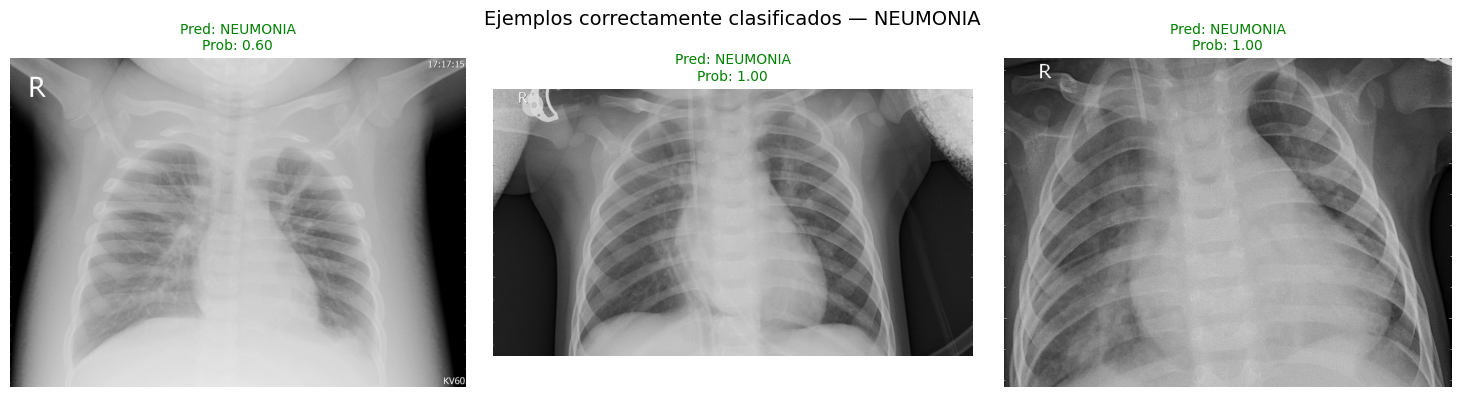

In [22]:
# --- Identificar aciertos ---
correct = np.where(test_preds == y_true)[0]

# --- Separar aciertos por clase ---
correct_normal = [i for i in correct if y_true[i] == 0]  # NORMAL
correct_pneumonia = [i for i in correct if y_true[i] == 1]  # PNEUMONIA

print(f"✅ Aciertos NORMAL: {len(correct_normal)}")
print(f"✅ Aciertos NEUMONIA: {len(correct_pneumonia)}")

# --- Seleccionar hasta 5 ejemplos de cada clase ---
num_examples = 3
samples_normal = random.sample(correct_normal, min(num_examples, len(correct_normal)))
samples_pneumonia = random.sample(correct_pneumonia, min(num_examples, len(correct_pneumonia)))

# --- Función para mostrar imágenes ---
def show_examples(indices, title):
    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(indices, 1):
        img_path = test_flow.filepaths[idx]
        true_label = "NEUMONIA" if y_true[idx] == 1 else "NORMAL"
        pred_label = "NEUMONIA" if test_preds[idx] == 1 else "NORMAL"
        prob = test_probs[idx][0]
        img = plt.imread(img_path)
        plt.subplot(1, len(indices), i)
        plt.imshow(img, cmap="gray")
        plt.title(f"Pred: {pred_label}\nProb: {prob:.2f}", color="green", fontsize=10)
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# --- Mostrar 5 ejemplos correctos de cada clase ---
show_examples(samples_normal, "Ejemplos correctamente clasificados — NORMAL")
show_examples(samples_pneumonia, "Ejemplos correctamente clasificados — NEUMONIA")
